# Paper figures directly from PIConGPU openPMD / ADIOS2

This notebook reproduces the paper-figure workflow **without reduced H5 files**.
It reads directly from:

```text
SIM_OUTPUT/openPMD/*.bp5
```

The reading pattern follows the working `ana_004.ipynb`/`NanoPlasmaRun` approach:

```python
with adios2.Stream(file, "r") as f:
    for _ in f.steps():
        data = f.read("/data/{step}/...")
```

No reduced H5 is created. Figures are displayed in the notebook. PNG saving is optional and disabled by default.


In [4]:
# =========================================================
# 0) Imports, local package bootstrap, and path configuration
# =========================================================

%matplotlib inline

# Keep native libraries conservative in Jupyter.
# This helps when ADIOS/HDF5/numpy would otherwise oversubscribe threads.
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

from pathlib import Path
import sys
import glob
import gc

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import scipy.constants as sc
import adios2


def find_repo_root(start=None, marker=("src", "nanoplasma_analysis")):
    """Find repo root by walking upward until src/nanoplasma_analysis exists."""
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for p in [start, *start.parents]:
        candidate = p / marker[0] / marker[1]
        if candidate.exists() and candidate.is_dir():
            return p

    # JURECA/JUWELS-style fallback used in this project.
    fallback = Path("/e/scratch/jureap18/medina2/PIConGPU_analisis")
    if (fallback / marker[0] / marker[1]).exists():
        return fallback

    raise FileNotFoundError(
        f"Could not find repo root from {start}. Expected src/nanoplasma_analysis."
    )


REPO = find_repo_root()
SRC = REPO / "src"
if str(SRC) in sys.path:
    sys.path.remove(str(SRC))
sys.path.insert(0, str(SRC))

# Use the raw/direct plotting class, not the H5 exporter class.
from nanoplasma_analysis.core import NanoPlasmaRun, extract_step_from_filename

print("Using repo:", REPO)
print("Using source:", SRC)
print("NanoPlasmaRun module:", NanoPlasmaRun.__module__)

# ---------------------------------------------------------
# USER PATHS: edit these only if needed
# ---------------------------------------------------------
SIM_OUTPUT = Path("/e/scratch/jureap18/medina2/tinkering/004_V1_LowDensity/simOutput")



LASER_PEAK_STEP = 89603
RUN_LABEL = SIM_OUTPUT.parent.name

# Optional figure saving. Disabled by default.
SAVE_FIGS = False
FIG_DIR = Path("/e/scratch/jureap18/medina2/bilder") / "paper_figures_direct"
if SAVE_FIGS:
    FIG_DIR.mkdir(exist_ok=True)

print("SIM_OUTPUT:", SIM_OUTPUT)
print("RUN_LABEL :", RUN_LABEL)
print("SAVE_FIGS:", SAVE_FIGS)
if SAVE_FIGS:
    print("FIG_DIR:", FIG_DIR)


Using repo: /e/scratch/jureap18/medina2/PIConGPU_analisis
Using source: /e/scratch/jureap18/medina2/PIConGPU_analisis/src
NanoPlasmaRun module: nanoplasma_analysis.core
SIM_OUTPUT: /e/scratch/jureap18/medina2/tinkering/004_V1_LowDensity/simOutput
RUN_LABEL : 004_V1_LowDensity
SAVE_FIGS: False


In [5]:
# =========================================================
# 1) Build run object and sanity-check available outputs
# =========================================================

run = NanoPlasmaRun(
    path=str(SIM_OUTPUT),
    laser_peak_at_target=LASER_PEAK_STEP,
)

run._load_meta()

steps = np.array([extract_step_from_filename(f) for f in run.files], dtype=int)
times_fs = np.array([run.time_fs_from_step(int(s)) for s in steps], dtype=float)

print("Number of openPMD outputs:", len(run.files))
print("First step/time:", steps[0], times_fs[0], "fs")
print("Last  step/time:", steps[-1], times_fs[-1], "fs")
print("Grid Nx,Ny,Nz:", run.Nx, run.Ny, run.Nz)
print("Cell dx,dy,dz (nm):", run.Dx_SI*1e9, run.Dy_SI*1e9, run.Dz_SI*1e9)
print("dt per PIConGPU step (fs):", run.dt_fs)

# Inspect one file.
fn0 = run.files[0]
step0 = extract_step_from_filename(fn0)
with adios2.Stream(fn0, "r") as f:
    for _ in f.steps():
        vars0 = sorted(f.available_variables().keys())
        attrs0 = sorted(f.available_attributes().keys())
        break

print("\nExample file:", fn0)
print("Example step:", step0)
print("Number of variables:", len(vars0))
print("First 20 variables:")
for v in vars0[:20]:
    print("  ", v)


Number of openPMD outputs: 23
First step/time: 0 -85.84881509818878 fs
Last  step/time: 325000 225.5343406768562 fs
Grid Nx,Ny,Nz: 1024 1600 1024
Cell dx,dy,dz (nm): 0.5 0.5 0.5
dt per PIConGPU step (fs): 0.0009581020177693692

Example file: /e/scratch/jureap18/medina2/tinkering/004_V1_LowDensity/simOutput/openPMD/simOutput_0.bp5
Example step: 0
Number of variables: 43
First 20 variables:
   /data/0/fields/B/x
   /data/0/fields/B/y
   /data/0/fields/B/z
   /data/0/fields/E/x
   /data/0/fields/E/y
   /data/0/fields/E/z
   /data/0/fields/He_e_all_density
   /data/0/fields/He_e_all_energyDensity
   /data/0/fields/He_i_all_boundElectronDensity
   /data/0/fields/He_i_all_density
   /data/0/fields/He_i_all_energyDensity
   /data/0/particles/He_e/particlePatches/extent/x
   /data/0/particles/He_e/particlePatches/extent/y
   /data/0/particles/He_e/particlePatches/extent/z
   /data/0/particles/He_e/particlePatches/numParticles
   /data/0/particles/He_e/particlePatches/numParticlesOffset
   /dat

## Helper functions: direct ADIOS2 readers

These helpers read one `.bp5` output at a time and immediately release the arrays. This avoids the reduced-H5 memory problem.


In [6]:
# =========================================================
# 2) Direct ADIOS helpers
# =========================================================

def nearest_file_index_for_time(run, target_fs):
    steps = np.array([extract_step_from_filename(f) for f in run.files], dtype=int)
    t = np.array([run.time_fs_from_step(int(s)) for s in steps], dtype=float)
    return int(np.argmin(np.abs(t - target_fs)))


def unique_nearest_indices_for_times(run, target_times_fs):
    idxs = []
    for tt in target_times_fs:
        i = nearest_file_index_for_time(run, tt)
        if i not in idxs:
            idxs.append(i)
    return idxs


def save_or_show(fig, name):
    if SAVE_FIGS:
        out = FIG_DIR / name
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("Saved:", out)
    plt.show()
    plt.close(fig)


def read_var(fn, step, var, start=None, count=None):
    """Read one ADIOS variable and return numpy array."""
    with adios2.Stream(str(fn), "r") as f:
        for _ in f.steps():
            if start is None:
                return f.read(var)
            return f.read(var, start=start, count=count)
    raise RuntimeError(f"Could not read {var} from {fn}")


def read_attr(fn, step, attr, default=None):
    with adios2.Stream(str(fn), "r") as f:
        for _ in f.steps():
            try:
                return f.read_attribute(attr)
            except Exception:
                return default
    return default


def has_var(fn, name):
    step = extract_step_from_filename(str(fn))
    with adios2.Stream(str(fn), "r") as f:
        for _ in f.steps():
            return name in f.available_variables()
    return False


def read_field_slice_xy(run, file_index, field="E/x", z_index=None):
    """Read field slice in x-y plane at fixed z. Returns array [y,x] in SI units."""
    run._load_meta()
    fn = run.files[file_index]
    step = extract_step_from_filename(fn)
    if z_index is None:
        z_index = int(run.Nz // 2)

    var = f"/data/{step}/fields/{field}"
    unit = read_attr(fn, step, f"{var}/unitSI", default=1.0)
    arr = read_var(fn, step, var, start=[z_index, 0, 0], count=[1, run.Ny, run.Nx])
    arr = np.asarray(arr)[0, :, :] * unit
    return arr


def read_field_slice_xz(run, file_index, field, y_nm=300.0):
    """Read field slice in x-z plane at fixed y. Returns array [z,x] in SI units."""
    run._load_meta()
    fn = run.files[file_index]
    step = extract_step_from_filename(fn)
    y_idx = int((y_nm * 1e-9) / run.Dy_SI)
    y_idx = max(0, min(run.Ny - 1, y_idx))

    var = f"/data/{step}/fields/{field}"
    if not has_var(fn, var):
        return None

    unit = read_attr(fn, step, f"{var}/unitSI", default=1.0)
    arr = read_var(fn, step, var, start=[0, y_idx, 0], count=[run.Nz, 1, run.Nx])
    arr = np.asarray(arr)[:, 0, :] * unit
    return arr


def weighted_histogram(values, weights, bins):
    h, edges = np.histogram(values, bins=bins, weights=weights)
    mid = 0.5 * (edges[1:] + edges[:-1])
    return mid, h


def hist_quantile(x_mid, counts, q=0.5):
    h = np.asarray(counts, dtype=float)
    h[~np.isfinite(h)] = 0.0
    total = h.sum()
    if total <= 0:
        return np.nan
    cdf = np.cumsum(h) / total
    j = int(np.searchsorted(cdf, q, side="left"))
    j = min(max(j, 0), len(x_mid) - 1)
    return float(x_mid[j])


def particle_count_direct(run, species):
    """Weighted macro-particle count from particlePatches/numParticles, same direct style as ana_004."""
    t_list = []
    n_list = []
    for fn in run.files:
        step = extract_step_from_filename(fn)
        t_list.append(run.time_fs_from_step(step))
        n_list.append(run._num_particles(fn, step, species))
    return np.asarray(t_list, float), np.asarray(n_list, float)


def particle_count_from_dat(run, species="He_e"):
    """Fast path from PIConGPU *_macroParticlesCount.dat if available."""
    run._load_meta()
    fn = Path(run.path) / f"{species}_macroParticlesCount.dat"
    if not fn.exists():
        print("Missing dat file, falling back to direct particlePatches:", fn)
        return particle_count_direct(run, species)
    nt, n = np.loadtxt(fn, usecols=(0, 1), unpack=True)
    t_fs = (nt - run.laser_peak_at_target) * run.dt_fs
    return np.asarray(t_fs, float), np.asarray(n, float)


# Figure 1 — Direct ADIOS storyboard maps

Paper logic: top row = normalized laser field component in the polarization plane; middle/bottom rows = electron and helium-core distributions. The paper describes Fig. 1 as spatio-temporal maps for the initially neutral target, with field maps in the polarization plane and electron/ion density maps in the propagation plane. The arXiv HTML caption describes the same structure for Fig. 1.


Fig1 read 1/6: index=1, step=35000, t=-52.32 fs
Fig1 read 2/6: index=3, step=75000, t=-13.99 fs
Fig1 read 3/6: index=4, step=85000, t=-4.41 fs
Fig1 read 4/6: index=5, step=95000, t=5.17 fs
Fig1 read 5/6: index=6, step=105000, t=14.75 fs
Fig1 read 6/6: index=9, step=135000, t=43.49 fs


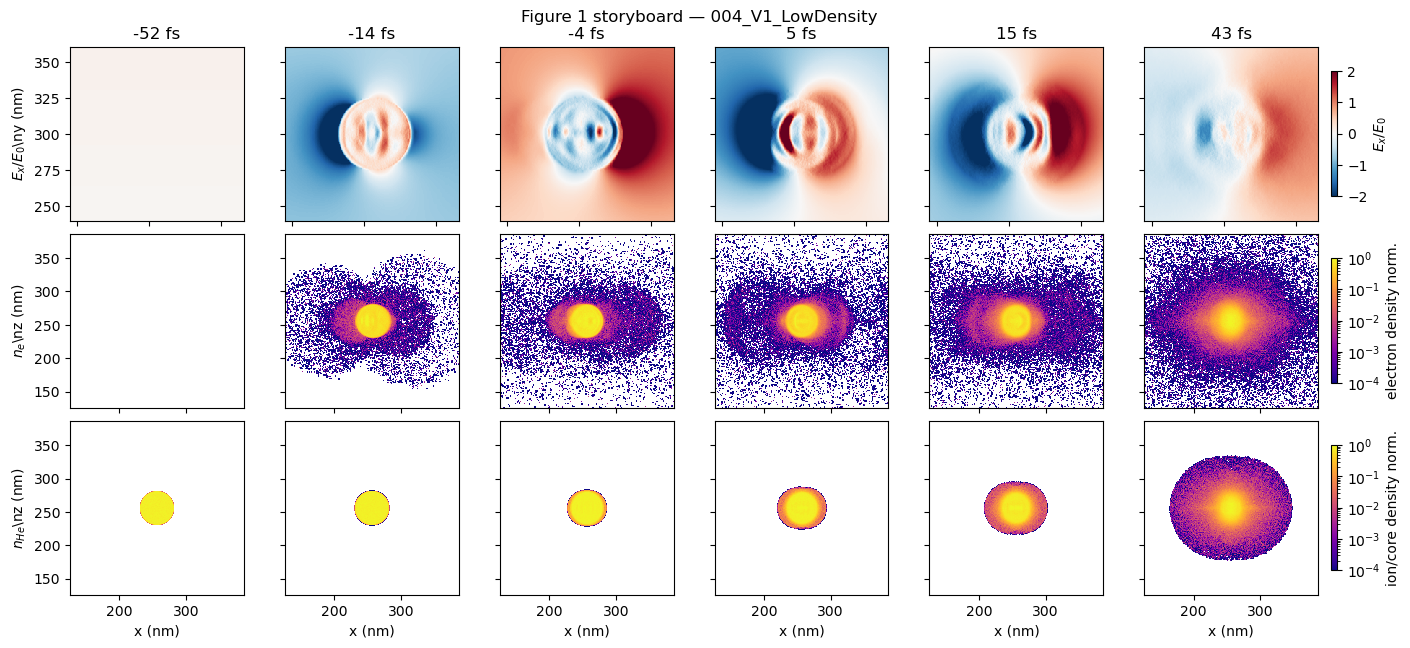

In [25]:
# =========================================================
# FIGURE 1: storyboard directly from fields in BP5
# =========================================================

# User knobs. Adjust times to the outputs you want in the storyboard.
FIG1_TIMES_FS = (-40,-10,0,5, 10,45)
FIG1_I0_WCM2 = 1e15
FIG1_SLICE_Y_NM = 300.0
FIG1_FIELD_VLIM = 2.0
FIG1_LOGNORM_VMIN = 1e-4

# Field names as in the current PIConGPU output.
FIG1_E_FIELD = "E/x"
FIG1_ELECTRON_DENSITY_FIELD = "He_e_all_density"
FIG1_ION_DENSITY_FIELD = "He_i_all_density"

# Manual crop knobs. Set C* to None for centered crop.

# Top row: E-field crop in x-y plane
CX_E, CY_E = 510, 600
HALF_E_X, HALF_E_Y = 120, 120 # wider in x, narrower in y

# Middle/bottom rows: electron/ion crop in x-z plane
CX_XZ, CZ_XZ = None, None
HALF_XZ_X, HALF_XZ_Z = 260, 260


def crop2d_centered(arr, cx=None, cy=None, half_x=100, half_y=100):
    """Crop arr[y,x]."""
    ny, nx = arr.shape
    if cx is None:
        cx = nx // 2
    if cy is None:
        cy = ny // 2
    x0 = max(0, int(cx - half_x)); x1 = min(nx, int(cx + half_x + 1))
    y0 = max(0, int(cy - half_y)); y1 = min(ny, int(cy + half_y + 1))
    return arr[y0:y1, x0:x1], (x0, x1, y0, y1)


def extent_nm_from_crop(crop_bounds, dx_nm, dy_nm):
    x0, x1, y0, y1 = crop_bounds
    return [x0 * dx_nm, x1 * dx_nm, y0 * dy_nm, y1 * dy_nm]


def normalize_density_for_lognorm(arr):
    arr = np.asarray(arr, float)
    arr = np.abs(arr)
    m = np.nanmax(arr)
    if not np.isfinite(m) or m <= 0:
        return np.full_like(arr, np.nan)
    out = arr / m
    out[out <= 0] = np.nan
    return out


def plot_storyboard_direct_adios(run, target_times_fs=FIG1_TIMES_FS):
    run._load_meta()

    indices = unique_nearest_indices_for_times(run, target_times_fs)
    ncols = len(indices)

    dx_nm = run.Dx_SI * 1e9
    dy_nm = run.Dy_SI * 1e9
    dz_nm = run.Dz_SI * 1e9

    E0 = np.sqrt(2 * FIG1_I0_WCM2 * 1e4 / (sc.c * sc.epsilon_0))

    fig, axes = plt.subplots(3, ncols, figsize=(2.35*ncols, 6.2), constrained_layout=True)
    if ncols == 1:
        axes = axes.reshape(3, 1)

    last_im_field = None
    last_im_e = None
    last_im_i = None

    for col, idx in enumerate(indices):
        fn = run.files[idx]
        step = extract_step_from_filename(fn)
        t_fs = run.time_fs_from_step(step)

        print(f"Fig1 read {col+1}/{ncols}: index={idx}, step={step}, t={t_fs:.2f} fs")

        # Top: E_x in x-y plane at z center.
        Ex_xy = read_field_slice_xy(run, idx, field=FIG1_E_FIELD) / E0
        Ex_crop, bxy = crop2d_centered(
            Ex_xy,
            cx=CX_E,
            cy=CY_E,
            half_x=HALF_E_X,
            half_y=HALF_E_Y,
        )    
        extent_xy = extent_nm_from_crop(bxy, dx_nm, dy_nm)

        ax = axes[0, col]
        last_im_field = ax.imshow(
            Ex_crop,
            origin="lower",
            cmap="RdBu_r",
            vmin=-FIG1_FIELD_VLIM,
            vmax=FIG1_FIELD_VLIM,
            extent=extent_xy,
            aspect="equal",
            interpolation="nearest",
        )
        ax.set_title(f"{t_fs:.0f} fs")

        # Middle: electron density in x-z plane.
        rho_e = read_field_slice_xz(run, idx, FIG1_ELECTRON_DENSITY_FIELD, y_nm=FIG1_SLICE_Y_NM)
        ax = axes[1, col]
        if rho_e is None:
            ax.text(0.5, 0.5, f"missing\n{FIG1_ELECTRON_DENSITY_FIELD}", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
        else:
            rho_e_crop, bxz = crop2d_centered(rho_e, CX_XZ, CZ_XZ, HALF_XZ_X, HALF_XZ_Z)
            extent_xz = extent_nm_from_crop(bxz, dx_nm, dz_nm)
            last_im_e = ax.imshow(
                normalize_density_for_lognorm(rho_e_crop),
                origin="lower",
                cmap="plasma",
                norm=LogNorm(vmin=FIG1_LOGNORM_VMIN, vmax=1.0),
                extent=extent_xz,
                aspect="equal",
                interpolation="nearest",
            )

        # Bottom: ion/core density in x-z plane.
        rho_i = read_field_slice_xz(run, idx, FIG1_ION_DENSITY_FIELD, y_nm=FIG1_SLICE_Y_NM)
        ax = axes[2, col]
        if rho_i is None:
            ax.text(0.5, 0.5, f"missing\n{FIG1_ION_DENSITY_FIELD}", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
        else:
            rho_i_crop, bxz = crop2d_centered(rho_i, CX_XZ, CZ_XZ, HALF_XZ_X, HALF_XZ_Z)
            extent_xz = extent_nm_from_crop(bxz, dx_nm, dz_nm)
            last_im_i = ax.imshow(
                normalize_density_for_lognorm(rho_i_crop),
                origin="lower",
                cmap="plasma",
                norm=LogNorm(vmin=FIG1_LOGNORM_VMIN, vmax=1.0),
                extent=extent_xz,
                aspect="equal",
                interpolation="nearest",
            )

        # Tick policy: only left column gets y labels; only bottom row gets x labels.
        for row in range(3):
            ax = axes[row, col]
            if col == 0:
                ax.set_ylabel([r"$E_x/E_0$\ny (nm)", r"$n_e$\nz (nm)", r"$n_{He}$\nz (nm)"][row])
            else:
                ax.set_yticklabels([])

            if row == 2:
                ax.set_xlabel("x (nm)")
            else:
                ax.set_xticklabels([])

    if last_im_field is not None:
        fig.colorbar(last_im_field, ax=axes[0, :], shrink=0.72, pad=0.01, label=r"$E_x/E_0$")
    if last_im_e is not None:
        fig.colorbar(last_im_e, ax=axes[1, :], shrink=0.72, pad=0.01, label="electron density norm.")
    if last_im_i is not None:
        fig.colorbar(last_im_i, ax=axes[2, :], shrink=0.72, pad=0.01, label="ion/core density norm.")

    fig.suptitle(f"Figure 1 storyboard — {RUN_LABEL}", y=1.02)
    save_or_show(fig, "fig1_direct.png")


plot_storyboard_direct_adios(run)


# Figure 2 — Ignition and early expansion directly from particles

This computes the same quantities used in the paper-style dynamics figure, but directly from the raw output files: electron yield, electron-generation rate, charge-state fractions, ion `R_rms/R0`, and mean electron density inside `R_rms` normalized to the critical density.


charge states 1/23 step=0 t=-85.85 fs
charge states 2/23 step=35000 t=-52.32 fs
charge states 3/23 step=70000 t=-18.78 fs
charge states 4/23 step=75000 t=-13.99 fs
charge states 5/23 step=85000 t=-4.41 fs
charge states 6/23 step=95000 t=5.17 fs
charge states 7/23 step=105000 t=14.75 fs
charge states 8/23 step=115000 t=24.33 fs
charge states 9/23 step=125000 t=33.91 fs
charge states 10/23 step=135000 t=43.49 fs
charge states 11/23 step=145000 t=53.08 fs
charge states 12/23 step=155000 t=62.66 fs
charge states 13/23 step=165000 t=72.24 fs
charge states 14/23 step=175000 t=81.82 fs
charge states 15/23 step=185000 t=91.40 fs
charge states 16/23 step=195000 t=100.98 fs
charge states 17/23 step=205000 t=110.56 fs
charge states 18/23 step=215000 t=120.14 fs
charge states 19/23 step=225000 t=129.72 fs
charge states 20/23 step=250000 t=153.68 fs
charge states 21/23 step=275000 t=177.63 fs
charge states 22/23 step=300000 t=201.58 fs
charge states 23/23 step=325000 t=225.53 fs
radial metrics 1/23

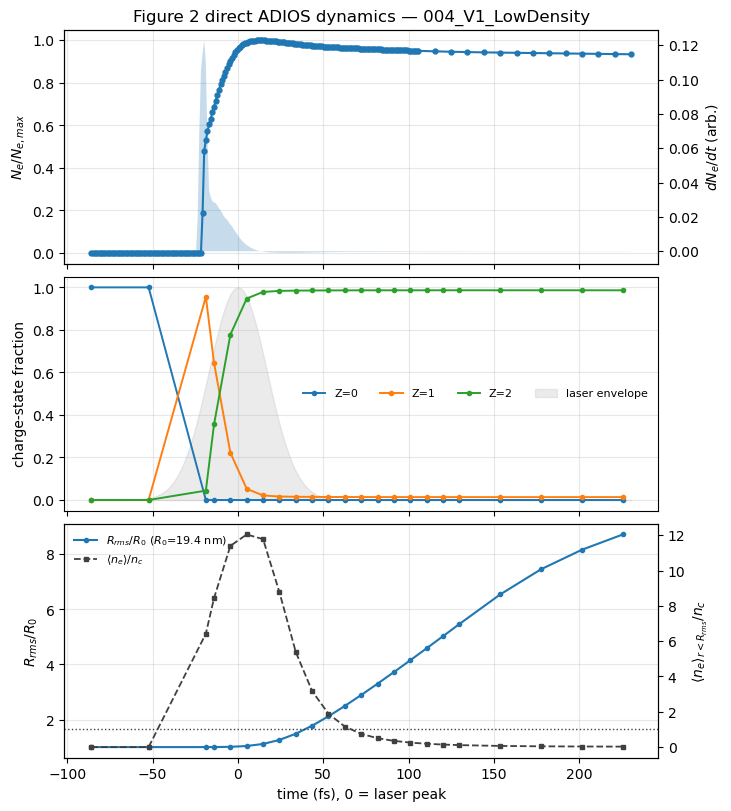

In [26]:
# =========================================================
# FIGURE 2: direct dynamics from raw particles
# =========================================================

FIG2_TAU_FWHM_FS = 40.0
FIG2_I0_WCM2 = 1e14
FIG2_LAMBDA_UM = 0.8
FIG2_ZMAX = 2
FIG2_R0_NM = None  # None -> use first non-empty ion RMS radius as R0. Or set 25.0 for paper value.
FIG2_T_RANGE_FS = None  # e.g. (-40, 130)


def charge_state_fractions_direct(run, ion_species="He_i", Zmax=2):
    t_list = []
    frac_list = []
    N_list = []

    bins = np.arange(-0.5, Zmax + 1.5, 1.0)

    for k, fn in enumerate(run.files):
        step = extract_step_from_filename(fn)
        t = run.time_fs_from_step(step)
        print(f"charge states {k+1}/{len(run.files)} step={step} t={t:.2f} fs")

        try:
            with adios2.Stream(str(fn), "r") as f:
                for _ in f.steps():
                    base = f"/data/{step}/particles/{ion_species}"
                    be = f.read(f"{base}/boundElectrons")
                    w = f.read(f"{base}/weighting")
                    break
        except Exception as e:
            print("  skip:", repr(e))
            continue

        Z = Zmax - np.asarray(be)
        hist, _ = np.histogram(Z, bins=bins, weights=w)
        total = np.sum(hist)
        frac = hist / total if total > 0 else np.full(Zmax + 1, np.nan)

        t_list.append(t)
        frac_list.append(frac)
        N_list.append(total)

        del be, w, Z, hist
        gc.collect()

    t = np.asarray(t_list, float)
    frac = np.asarray(frac_list, float)
    N = np.asarray(N_list, float)
    order = np.argsort(t)
    return t[order], frac[order], N[order]


def radial_and_density_metrics_direct(
    run,
    ion_species="He_i",
    e_species="He_e",
    lambda_um=0.8,
    R0_nm=None,
):
    """
    Computes:
      R_rms/R0 from ion positions, relative to first ion COM.
      mean electron density inside R_rms using electron positions and weights.

    This follows the paper convention remembered for Fig. 2: mean electron density inside R_rms,
    normalized to n_crit, without explicit shell-volume weighting.
    """
    run._load_meta()

    t_list = []
    R_rms_nm_list = []
    ne_inside_list = []

    r0 = None
    R0_m = None if R0_nm is None else R0_nm * 1e-9

    # critical density for laser wavelength
    omega = 2 * np.pi * sc.c / (lambda_um * 1e-6)
    ncrit = sc.epsilon_0 * sc.m_e * omega**2 / sc.e**2

    for k, fn in enumerate(run.files):
        step = extract_step_from_filename(fn)
        t = run.time_fs_from_step(step)
        print(f"radial metrics {k+1}/{len(run.files)} step={step} t={t:.2f} fs")

        xi, yi, zi, wi = run._read_positions_and_weight(fn, step, ion_species)
        if xi is None or wi is None or np.sum(wi) <= 0:
            t_list.append(t)
            R_rms_nm_list.append(np.nan)
            ne_inside_list.append(np.nan)
            continue

        wi_sum = np.sum(wi)
        ion_com = np.array([
            np.sum(wi * xi) / wi_sum,
            np.sum(wi * yi) / wi_sum,
            np.sum(wi * zi) / wi_sum,
        ])

        if r0 is None:
            r0 = ion_com.copy()

        ri = np.sqrt((xi-r0[0])**2 + (yi-r0[1])**2 + (zi-r0[2])**2)
        R_rms_m = np.sqrt(np.sum(wi * ri**2) / wi_sum)

        if R0_m is None and np.isfinite(R_rms_m) and R_rms_m > 0:
            R0_m = R_rms_m

        # electron density inside instantaneous ion R_rms
        xe, ye, ze, we = run._read_positions_and_weight(fn, step, e_species)
        if xe is None or we is None or R_rms_m <= 0:
            ne_inside = 0.0
        else:
            re = np.sqrt((xe-r0[0])**2 + (ye-r0[1])**2 + (ze-r0[2])**2)
            Ne_inside = np.sum(we[re <= R_rms_m])
            V = (4.0/3.0) * np.pi * R_rms_m**3
            ne_inside = Ne_inside / V if V > 0 else np.nan

        t_list.append(t)
        R_rms_nm_list.append(R_rms_m * 1e9)
        ne_inside_list.append(ne_inside)

        del xi, yi, zi, wi
        if 'xe' in locals():
            del xe, ye, ze, we
        gc.collect()

    t = np.asarray(t_list, float)
    R_rms_nm = np.asarray(R_rms_nm_list, float)
    ne_inside = np.asarray(ne_inside_list, float)

    R0_nm_used = R0_m * 1e9 if R0_m is not None else np.nan
    R_norm = R_rms_nm / R0_nm_used
    ne_over_nc = ne_inside / ncrit

    order = np.argsort(t)
    return t[order], R_norm[order], ne_over_nc[order], R0_nm_used, ncrit


def smooth_moving_average(y, window=5):
    y = np.asarray(y, float)
    if window is None or window <= 1:
        return y
    window = int(window)
    if window % 2 == 0:
        window += 1
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode="same")


def plot_fig2_dynamics_direct(run):
    # electron yield from dat if available, otherwise from particlePatches.
    tN, Ne = particle_count_from_dat(run, "He_e")
    order = np.argsort(tN)
    tN, Ne = tN[order], Ne[order]
    Ne_norm = Ne / np.nanmax(Ne) if np.nanmax(Ne) > 0 else Ne
    dNe_dt = np.gradient(Ne_norm, tN)
    dNe_dt_s = smooth_moving_average(dNe_dt, window=5)

    tZ, fracZ, Ni = charge_state_fractions_direct(run, "He_i", Zmax=FIG2_ZMAX)
    tR, R_norm, ne_nc, R0_nm_used, ncrit = radial_and_density_metrics_direct(
        run,
        "He_i",
        "He_e",
        lambda_um=FIG2_LAMBDA_UM,
        R0_nm=FIG2_R0_NM,
    )

    t_dense = np.linspace(np.nanmin(tN), np.nanmax(tN), 1000)
    I_dense = FIG2_I0_WCM2 * np.exp(-4*np.log(2)*(t_dense/FIG2_TAU_FWHM_FS)**2)
    I_norm = I_dense / np.nanmax(I_dense)

    fig, axes = plt.subplots(3, 1, figsize=(7.2, 8.0), sharex=True, constrained_layout=True)

    ax = axes[0]
    ax.plot(tN, Ne_norm, "o-", ms=3.5, lw=1.5, label=r"$N_e$ norm.")
    ax2 = ax.twinx()
    ax2.fill_between(tN, dNe_dt_s, 0, alpha=0.25, label=r"$dN_e/dt$")
    ax.set_ylabel(r"$N_e/N_{e,max}$")
    ax2.set_ylabel(r"$dN_e/dt$ (arb.)")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Figure 2 direct ADIOS dynamics — {RUN_LABEL}")

    ax = axes[1]
    for Z in range(fracZ.shape[1]):
        ax.plot(tZ, fracZ[:, Z], "o-", ms=3, lw=1.4, label=f"Z={Z}")
    ax.fill_between(t_dense, I_norm, 0, color="0.7", alpha=0.25, label="laser envelope")
    ax.set_ylabel("charge-state fraction")
    ax.legend(ncol=4, fontsize=8, frameon=False)
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    ax.plot(tR, R_norm, "o-", ms=3, lw=1.5, label=rf"$R_{{rms}}/R_0$ ($R_0$={R0_nm_used:.1f} nm)")
    ax.set_ylabel(r"$R_{rms}/R_0$")
    ax.set_xlabel("time (fs), 0 = laser peak")
    ax.grid(True, alpha=0.3)

    axr = ax.twinx()
    axr.plot(tR, ne_nc, "s--", ms=3, lw=1.3, color="0.25", label=rf"$\langle n_e\rangle/n_c$")
    axr.axhline(1.0, color="0.25", lw=1.0, ls=":")
    axr.set_ylabel(r"$\langle n_e\rangle_{r<R_{rms}}/n_c$")

    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = axr.get_legend_handles_labels()
    ax.legend(lines+lines2, labels+labels2, fontsize=8, frameon=False, loc="upper left")

    if FIG2_T_RANGE_FS is not None:
        axes[-1].set_xlim(FIG2_T_RANGE_FS)

    save_or_show(fig, "fig2_dynamics_direct_adios.png")
    return dict(tN=tN, Ne=Ne, tZ=tZ, fracZ=fracZ, tR=tR, R_norm=R_norm, ne_nc=ne_nc)


fig2_data = plot_fig2_dynamics_direct(run)


# Figure 3 — Electron angular distribution and asymmetry directly from particle positions

The paper figure describes the angular distribution of the electron cloud relative to the laser polarization axis using the electron position vector relative to the droplet center. This cell therefore uses particle positions, not momenta. If you want the old `ana_004` momentum version, switch `USE_POSITION_ANGLE=False`.


angular 3/23 step=70000 t=-18.78 fs
angular 4/23 step=75000 t=-13.99 fs
angular 5/23 step=85000 t=-4.41 fs
angular 6/23 step=95000 t=5.17 fs
angular 7/23 step=105000 t=14.75 fs
angular 8/23 step=115000 t=24.33 fs
angular 9/23 step=125000 t=33.91 fs
angular 10/23 step=135000 t=43.49 fs
angular 11/23 step=145000 t=53.08 fs
angular 12/23 step=155000 t=62.66 fs
angular 13/23 step=165000 t=72.24 fs


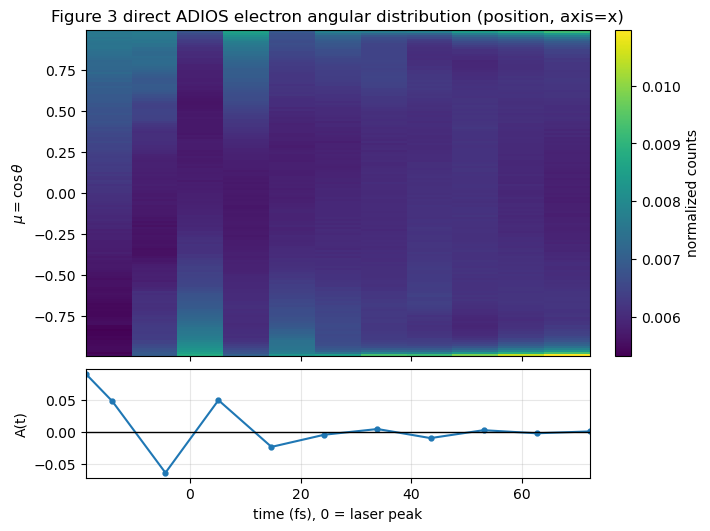

In [27]:
# =========================================================
# FIGURE 3: angular distribution and asymmetry from raw particles
# =========================================================

FIG3_AXIS = "x"          # laser polarization axis
FIG3_N_MU = 160
FIG3_T_RANGE_FS = (-40, 80)
USE_POSITION_ANGLE = True


def get_reference_center_from_ions(run, ion_species="He_i"):
    """First non-empty ion center of mass."""
    for fn in run.files:
        step = extract_step_from_filename(fn)
        x, y, z, w = run._read_positions_and_weight(fn, step, ion_species)
        if x is None or w is None or np.sum(w) <= 0:
            continue
        return np.array([np.sum(w*x)/np.sum(w), np.sum(w*y)/np.sum(w), np.sum(w*z)/np.sum(w)])
    return np.zeros(3)


def angular_distribution_vs_time_direct(
    run,
    species="He_e",
    axis="x",
    n_mu=160,
    use_position=True,
    t_range_fs=None,
):
    mu_edges = np.linspace(-1, 1, n_mu+1)
    mu_mid = 0.5*(mu_edges[1:] + mu_edges[:-1])
    axis_index = {"x":0, "y":1, "z":2}[axis]
    center = get_reference_center_from_ions(run, "He_i")

    t_list = []
    H_list = []
    A_list = []

    for k, fn in enumerate(run.files):
        step = extract_step_from_filename(fn)
        t = run.time_fs_from_step(step)
        if t_range_fs is not None and not (t_range_fs[0] <= t <= t_range_fs[1]):
            continue

        print(f"angular {k+1}/{len(run.files)} step={step} t={t:.2f} fs")

        if use_position:
            x, y, z, w = run._read_positions_and_weight(fn, step, species)
            if x is None or w is None:
                continue
            vecs = [x-center[0], y-center[1], z-center[2]]
        else:
            px, py, pz, w = run._read_momentum_and_weight(fn, step, species)
            if px is None or w is None:
                continue
            vecs = [px, py, pz]

        r = np.sqrt(vecs[0]**2 + vecs[1]**2 + vecs[2]**2) + 1e-300
        mu = vecs[axis_index] / r

        hist, _ = np.histogram(mu, bins=mu_edges, weights=w)
        total = np.sum(hist)
        if total <= 0:
            continue
        hist_norm = hist / total
        A = (np.sum(w[mu > 0]) - np.sum(w[mu < 0])) / (np.sum(w[mu > 0]) + np.sum(w[mu < 0]) + 1e-300)

        t_list.append(t)
        H_list.append(hist_norm)
        A_list.append(A)

        del mu, hist, w, vecs, r
        gc.collect()

    t = np.asarray(t_list, float)
    H = np.asarray(H_list, float)
    A = np.asarray(A_list, float)
    order = np.argsort(t)
    return t[order], mu_mid, H[order], A[order]


def plot_fig3_angular_direct(run):
    t, mu_mid, H, A = angular_distribution_vs_time_direct(
        run,
        species="He_e",
        axis=FIG3_AXIS,
        n_mu=FIG3_N_MU,
        use_position=USE_POSITION_ANGLE,
        t_range_fs=FIG3_T_RANGE_FS,
    )

    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7.0, 5.2), sharex=True, constrained_layout=True,
                                   gridspec_kw={"height_ratios":[3,1]})

    im = ax0.imshow(
        H.T,
        origin="lower",
        aspect="auto",
        extent=[t.min(), t.max(), mu_mid[0], mu_mid[-1]],
        interpolation="nearest",
    )
    fig.colorbar(im, ax=ax0, label="normalized counts")
    ax0.set_ylabel(r"$\mu=\cos\theta$")
    label = "position" if USE_POSITION_ANGLE else "momentum"
    ax0.set_title(f"Figure 3 direct ADIOS electron angular distribution ({label}, axis={FIG3_AXIS})")

    ax1.plot(t, A, "o-", ms=3.5, lw=1.5)
    ax1.axhline(0, color="k", lw=1)
    ax1.set_xlabel("time (fs), 0 = laser peak")
    ax1.set_ylabel("A(t)")
    ax1.grid(True, alpha=0.3)

    save_or_show(fig, "fig3_angular_direct_adios.png")
    return t, mu_mid, H, A


fig3_data = plot_fig3_angular_direct(run)


# Figure 4 — Electron and ion kinetic-energy spectra directly from momentum arrays

This reproduces the paper-style spectral lineouts and median-energy insets without using `/spectra` from a reduced H5. Each requested time is read directly from the corresponding `.bp5` output.


In [ ]:
# =========================================================
# FIGURE 4: energy spectra directly from raw particle momenta
# corrected histogram/binning version
# =========================================================

FIG4_TIMES_FS = ( -10,-5, 0, 5, 10, 20, 40, 80, 160, 250)

# Main control knobs
FIG4_E_MAX_EV = 200.0          # your diagnostic showed energies mostly < 100 eV
FIG4_N_BINS = 600
FIG4_BINNING = "linear"        # "linear" or "log"
FIG4_XSCALE = "linear"         # "linear" or "log"
FIG4_YSCALE = "log"            # keep log y
FIG4_Y_MODE = "counts"         # "counts" or "dNdE"

# Axis limits. For log x, lower limit must be > 0.
if FIG4_XSCALE == "log":
    FIG4_XLIM_EV = (0.05, FIG4_E_MAX_EV)
else:
    FIG4_XLIM_EV = (0.0, FIG4_E_MAX_EV)


def make_energy_edges(E_max_eV, n_bins, binning="linear", Emin_log_eV=0.05):
    """
    Make energy-bin edges.

    linear:
        edges from 0 to E_max_eV

    log:
        edges from Emin_log_eV to E_max_eV
        use only if the x-axis is log or if you really want log-spaced bins.
    """
    if binning == "linear":
        return np.linspace(0.0, E_max_eV, n_bins + 1)

    if binning == "log":
        return np.logspace(np.log10(Emin_log_eV), np.log10(E_max_eV), n_bins + 1)

    raise ValueError("binning must be 'linear' or 'log'")


FIG4_E_BINS_EV = make_energy_edges(
    FIG4_E_MAX_EV,
    FIG4_N_BINS,
    binning=FIG4_BINNING,
)


def bin_centers_from_edges(edges, binning="linear"):
    """
    Correct bin centers.

    For linear bins, use arithmetic centers.
    For log bins, use geometric centers.
    """
    edges = np.asarray(edges)

    if binning == "log":
        return np.sqrt(edges[:-1] * edges[1:])

    return 0.5 * (edges[:-1] + edges[1:])


def weighted_quantile_from_samples(values, weights, q=0.90):
    """
    Weighted quantile directly from particle energies.
    More robust than estimating median from already-binned histograms.
    """
    values = np.asarray(values)
    weights = np.asarray(weights)

    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[mask]
    weights = weights[mask]

    if values.size == 0:
        return np.nan

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]

    cdf = np.cumsum(weights)
    cdf = cdf / cdf[-1]

    return np.interp(q, cdf, values)


def kinetic_energy_spectrum_one(run, file_index, species, E_edges_eV):
    """
    Read one timestep directly from ADIOS/openPMD and return a clean histogram.

    Important fixes:
    - correct bin centers for linear/log bins
    - no artificial +1e-300 floor in the returned histogram
    - median computed from raw weighted particle energies
    """
    fn = run.files[file_index]
    step = extract_step_from_filename(fn)

    px, py, pz, w = run._read_momentum_and_weight(fn, step, species)

    E_mid = bin_centers_from_edges(E_edges_eV, FIG4_BINNING)

    if px is None or w is None:
        return E_mid, np.zeros_like(E_mid), np.nan

    mass = run._mass_kg(species)

    E_eV = (px*px + py*py + pz*pz) / (2.0 * mass) / sc.e

    hist, edges = np.histogram(E_eV, bins=E_edges_eV, weights=w)

    if FIG4_Y_MODE == "dNdE":
        y = hist / np.diff(edges)
    elif FIG4_Y_MODE == "counts":
        y = hist
    else:
        raise ValueError("FIG4_Y_MODE must be 'counts' or 'dNdE'")

    med = weighted_quantile_from_samples(E_eV, w, q=0.5)

    print(
        f"  {species}: "
        f"Nmacro={len(E_eV)}, "
        f"Emin={np.nanmin(E_eV):.3g} eV, "
        f"Emax={np.nanmax(E_eV):.3g} eV, "
        f"E50={med:.3g} eV"
    )

    del px, py, pz, w, E_eV
    gc.collect()

    return E_mid, y, med


def plot_positive_log_line(ax, E, y, **kwargs):
    """
    Plot spectra safely on log-y axes.

    Do NOT do y + 1e-300.
    That creates fake floor lines and makes spectra look weird.
    Instead, mask zero bins.
    """
    y_plot = np.asarray(y, dtype=float).copy()
    y_plot[~np.isfinite(y_plot)] = np.nan
    y_plot[y_plot <= 0] = np.nan

    ax.plot(E, y_plot, **kwargs)


def plot_fig4_spectra_direct(run):
    idxs = unique_nearest_indices_for_times(run, FIG4_TIMES_FS)
    actual_times = [
        run.time_fs_from_step(extract_step_from_filename(run.files[i]))
        for i in idxs
    ]

    fig, (ax_e, ax_i) = plt.subplots(
        2, 1,
        figsize=(6.2, 7.0),
        sharex=True,
        gridspec_kw={"hspace": 0.0},
    )

    med_e = []
    med_i = []
    t_sel = []

    for i, t in zip(idxs, actual_times):
        print(f"\nspectra read index={i}, t={t:.2f} fs")

        E_e, He, me = kinetic_energy_spectrum_one(
            run,
            i,
            "He_e",
            FIG4_E_BINS_EV,
        )

        E_i, Hi, mi = kinetic_energy_spectrum_one(
            run,
            i,
            "He_i",
            FIG4_E_BINS_EV,
        )

        plot_positive_log_line(
            ax_e,
            E_e,
            He,
            lw=1.8,
            label=f"{t:.0f} fs",
        )

        plot_positive_log_line(
            ax_i,
            E_i,
            Hi,
            lw=1.8,
            label=f"{t:.0f} fs",
        )

        med_e.append(me)
        med_i.append(mi)
        t_sel.append(t)

        del He, Hi
        gc.collect()

    ylabel = "counts/bin" if FIG4_Y_MODE == "counts" else r"dN/dE"

    ax_e.set_ylabel(r"e$^-$ " + ylabel)
    ax_i.set_ylabel("ion " + ylabel)
    ax_i.set_xlabel("kinetic energy (eV)")
    ax_e.set_title("Figure 4 direct ADIOS kinetic-energy spectra")

    ax_i.legend(
        loc="upper left",
        fontsize=8,
        frameon=False,
        ncol=2,
    )

    # Scales
    ax_e.set_yscale(FIG4_YSCALE)
    ax_i.set_yscale(FIG4_YSCALE)

    ax_e.set_xscale(FIG4_XSCALE)
    ax_i.set_xscale(FIG4_XSCALE)

    if FIG4_XLIM_EV is not None:
        ax_i.set_xlim(FIG4_XLIM_EV)

    # Avoid impossible lower limit for log x
    if FIG4_XSCALE == "log":
        ax_i.set_xlim(max(FIG4_XLIM_EV[0], 1e-6), FIG4_XLIM_EV[1])

    ax_e.grid(True, alpha=0.25)
    ax_i.grid(True, alpha=0.25)

    t_sel = np.asarray(t_sel)
    med_e = np.asarray(med_e)
    med_i = np.asarray(med_i)

    order = np.argsort(t_sel)

    # Keep insets: they were good
    axins_e = inset_axes(
        ax_e,
        width="42%",
        height="42%",
        loc="upper right",
        borderpad=1.6,
    )
    axins_e.plot(t_sel[order], med_e[order], ".--", color="0.35")
    axins_e.set_title("e⁻ median", fontsize=9)
    axins_e.set_xlabel("t (fs)", fontsize=8)
    axins_e.set_ylabel("E50 (eV)", fontsize=8)
    axins_e.tick_params(labelsize=8)
    axins_e.grid(True, alpha=0.25)

    axins_i = inset_axes(
        ax_i,
        width="42%",
        height="42%",
        loc="upper right",
        borderpad=1.6,
    )
    axins_i.plot(t_sel[order], med_i[order], ".--", color="0.35")
    axins_i.set_title("ion median", fontsize=9)
    axins_i.set_xlabel("t (fs)", fontsize=8)
    axins_i.set_ylabel("E50 (eV)", fontsize=8)
    axins_i.tick_params(labelsize=8)
    axins_i.grid(True, alpha=0.25)

    plt.tight_layout()
    save_or_show(fig, "fig4_spectra_direct_adios.png")

    return {
        "t": t_sel[order],
        "med_e": med_e[order],
        "med_i": med_i[order],
    }


fig4_data = plot_fig4_spectra_direct(run)

# Figure 5-style simulated electron VMI directly from momentum arrays

This gives the simulation-side VMI panel without reduced H5. Experimental comparison still needs the separate experimental H5/data files, so this cell only builds the simulated VMI image directly from the `.bp5` particle momenta.


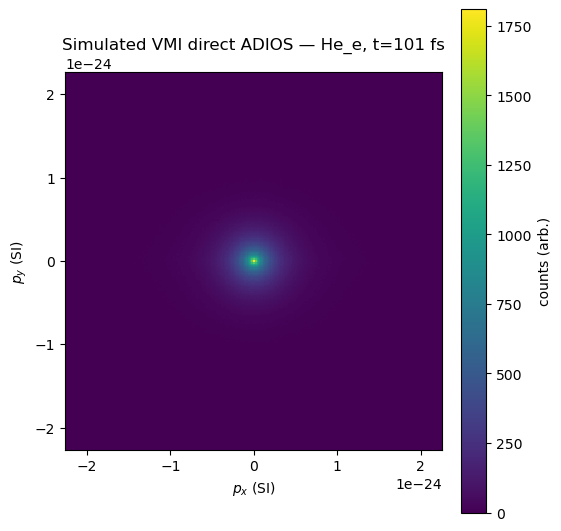

In [47]:
# =========================================================
# FIGURE 5 helper: simulated VMI directly from raw particle momenta
# =========================================================

FIG5_TIME_FS = 100
FIG5_SPECIES = "He_e"
FIG5_PLANE = ("x", "y")
FIG5_P_BINS = 300
FIG5_PERCENTILE_RANGE = 99.5  # crop histogram range to percentile of |p|


def plot_vmi_direct_adios(run, time_fs=FIG5_TIME_FS, species=FIG5_SPECIES, plane=FIG5_PLANE):
    idx = nearest_file_index_for_time(run, time_fs)
    fn = run.files[idx]
    step = extract_step_from_filename(fn)
    t = run.time_fs_from_step(step)

    px, py, pz, w = run._read_momentum_and_weight(fn, step, species)
    if px is None or w is None:
        print(f"No particles for {species} at t={t:.2f} fs")
        return None

    comp = {"x": px, "y": py, "z": pz}
    a, b = plane
    pa = comp[a]
    pb = comp[b]

    pabs = np.sqrt(pa*pa + pb*pb)
    pmax = np.nanpercentile(pabs, FIG5_PERCENTILE_RANGE)
    if not np.isfinite(pmax) or pmax <= 0:
        pmax = np.nanmax(np.abs(np.r_[pa, pb]))

    edges = np.linspace(-pmax, pmax, FIG5_P_BINS+1)
    H, xed, yed = np.histogram2d(pa, pb, bins=[edges, edges], weights=w)

    fig, ax = plt.subplots(figsize=(5.5, 5.2), constrained_layout=True)
    im = ax.imshow(
        H.T,
        origin="lower",
        extent=[xed[0], xed[-1], yed[0], yed[-1]],
        aspect="equal",
        interpolation="nearest",
    )
    fig.colorbar(im, ax=ax, label="counts (arb.)")
    ax.set_xlabel(fr"$p_{a}$ (SI)")
    ax.set_ylabel(fr"$p_{b}$ (SI)")
    ax.set_title(f"Simulated VMI direct ADIOS — {species}, t={t:.0f} fs")

    save_or_show(fig, f"fig5_vmi_{species}_direct_adios.png")

    del px, py, pz, w, pa, pb, pabs, H
    gc.collect()
    return xed, yed


vmi_direct_result = plot_vmi_direct_adios(run)


## Optional: run the original `ana_004` style quick plots

These use the working `NanoPlasmaRun` methods directly. They are kept as quick diagnostics.


In [ ]:
# Quick diagnostics, same spirit as ana_004. Uncomment as needed.

# run.plot_particle_number(species="He_e")
# run.plot_charge_state_evolution(ion_species="He_i", Zmax=2, show_laser_envelope=True,
#                                 tau_fwhm_fs=40.0, I0_Wcm2=1e14, lambda_um=0.8)
# run.plot_laser_envelope_and_electron_yield(species="He_e", tau_fwhm_fs=40.0, I0_Wcm2=1e14, lambda_um=0.8)
# run.plot_kinetic_energy_spectra(species="He_e", file_indices=[-1], bins=(0, 200, 300), normalize=False, logy=True)
# run.plot_kinetic_energy_spectra(species="He_i", file_indices="all", bins=(0, 200, 300), normalize=False, logy=True)
# run.plot_vmi(species="He_e", file_index=-1, plane=("x", "y"), Nbins=250)


## Notes

- This notebook reads the raw `.bp5` files directly and does **not** create reduced H5 files.
- It intentionally processes one output file at a time to reduce memory pressure in Jupyter.
- Figure 1 uses field/density arrays; Figure 2–5 use particle arrays or macro-particle count files where available.
- For paper-quality final figures, tune the time selections and crop centers at the top of each figure cell.
